## Banking Portfolio Performance & Loan Risk Insights

In [1]:
#install sql alchemy and pyodbc
!pip install sqlalchemy pyodbc pandas

In [2]:
import sqlalchemy
import pyodbc
import pandas as pd

print("All packages installed successfully!")

All packages installed successfully!


In [3]:
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine(
    "mssql+pyodbc://@Jiya\\MSSQL/banking?"
    "driver=ODBC+Driver+17+for+SQL+Server"
)

df = pd.read_sql("SELECT * FROM customer_data", engine)

print(df.head())

C:\Users\jeevi\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1115.1'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


  Client_ID             Name  Age  Location_ID Joined_Bank   Banking_Contact  \
0  IND81288    Raymond Mills   24        34324  2019-05-06    Anthony Torres   
1  IND65833    Julia Spencer   23        42205  2001-12-10  Jonathan Hawkins   
2  IND47499   Stephen Murray   27         7314  2010-01-25     Anthony Berry   
3  IND72498   Virginia Garza   40        34594  2019-03-28        Steve Diaz   
4  IND60181  Melissa Sanders   46        41269  2012-07-20        Shawn Long   

  Nationality            Occupation Fee_Structure Loyalty_Classification  ...  \
0    American  Safety Technician IV          High                   Jade  ...   
1     African   Software Consultant          High                   Jade  ...   
2    European    Help Desk Operator          High                   Gold  ...   
3    American          Geologist II           Mid                 Silver  ...   
4    American   Assistant Professor           Mid               Platinum  ...   

   Bank_Deposits  Checking_Accou

### Exploratory Data Analysis

In [4]:
#Install Necessary Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
#Understanding Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client_ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location_ID               3000 non-null   int64  
 4   Joined_Bank               3000 non-null   object 
 5   Banking_Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee_Structure             3000 non-null   object 
 9   Loyalty_Classification    3000 non-null   object 
 10  Estimated_Income          3000 non-null   float64
 11  Superannuation_Savings    3000 non-null   float64
 12  Amount_of_Credit_Cards    3000 non-null   int64  
 13  Credit_Card_Balance       3000 non-null   float64
 14  Bank_Loa

In [6]:
df.shape

(3000, 25)

In [7]:
df.describe()

,Age,Location_ID,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,Credit_Card_Balance,Bank_Loans,Bank_Deposits,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034184,25531.599685,1.463667,3176.206944,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529998,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808180,16259.950768,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924033,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480469,1482.030029,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.597656,12513.774902,1.000000,1236.630005,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542236,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.476562,22357.355469,1.000000,2560.804932,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190430,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.300781,35464.741211,2.000000,4522.632690,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.391602,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.250000,75963.898438,3.000000,13991.990234,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.867188,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


### Data Cleaning

In [8]:
#check for missing values
df.isnull().sum()

Client_ID                   0
Name                        0
Age                         0
Location_ID                 0
Joined_Bank                 0
Banking_Contact             0
Nationality                 0
Occupation                  0
Fee_Structure               0
Loyalty_Classification      0
Estimated_Income            0
Superannuation_Savings      0
Amount_of_Credit_Cards      0
Credit_Card_Balance         0
Bank_Loans                  0
Bank_Deposits               0
Checking_Accounts           0
Saving_Accounts             0
Foreign_Currency_Account    0
Business_Lending            0
Properties_Owned            0
Risk_Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

In [9]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

### Fix Data

In [10]:
#Replacing GenderId with Gender
df['Gender'] = df['GenderId'].replace({
    1: 'Male',
    2: 'Female'
})

df.drop(columns=['GenderId'], inplace=True)

In [11]:
#Replacing BRId with Banking Relation ID Name
df['Banking_Relationship'] = df['BRId'].replace({
  1: 'Retail',
  2: 'Institutional',
  3: 'Private Bank',
  4: 'Commercial'
  
})
df.drop(columns=['BRId'], inplace=True)

In [12]:
#Replacing IAId with Investment Advisor names:
df['Investment_Advisor'] = df['IAId'].replace({
    1: 'Victor Dean',
    2: 'Jeremy Porter',
    3: 'Ernest Knight',
    4: 'Eric Shaw',
    5: 'Kevin Kim',
    6: 'Victor Rogers',
    7: 'Eugene Cunningham',
    8: 'Joe Carroll',
    9: 'Steve Sanchez',
    10: 'Lawrence Sanchez',
    11: 'Peter Castillo',
    12: 'Victor Gutierrez',
    13: 'Daniel Carroll',
    14: 'Carl Anderson',
    15: 'Nicholas Ward',
    16: 'Fred Bryant',
    17: 'Ryan Taylor',
    18: 'Sean Vasquez',
    19: 'Nicholas Morrison',
    20: 'Jack Phillips',
    21: 'Juan Ramirez',
    22: 'Gregory Boyd'
})
df.drop(columns=['IAId'], inplace=True)

In [13]:
#create bins for estimated income
bins = [0,100000,300000, float('inf')]
labels = ["Low", "Mid", "High"]

df['Income_Category'] = pd.cut(df['Estimated_Income'], bins=bins, labels=labels, right= False)

<Axes: xlabel='Income_Category'>

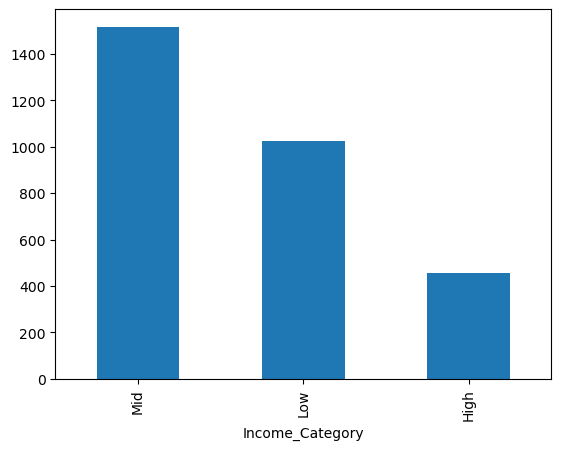

In [14]:
df['Income_Category'].value_counts().plot(kind='bar')

In [15]:
#Examine the unique distribution of categories in categorical column
from IPython.display import display

for col in ["Banking_Relationship","Gender","Investment_Advisor","Amount_of_Credit_Cards",
            "Nationality","Occupation","Fee_Structure",
            "Loyalty_Classification","Properties_Owned",
            "Risk_Weighting","Income_Category"]:
    
    print(f"\n{col}:")
    display(df[col].value_counts().reset_index(name="Count"))


Banking_Relationship:


,Banking_Relationship,Count
0,Private Bank,1352
1,Retail,660
2,Institutional,495
3,Commercial,493



Gender:


,Gender,Count
0,Female,1512
1,Male,1488



Investment_Advisor:


...

,Properties_Owned,Count
0,2,777
1,1,776
2,3,742
3,0,705



Risk_Weighting:


,Risk_Weighting,Count
0,2,1222
1,1,836
2,3,460
3,4,322
4,5,160



Income_Category:


,Income_Category,Count
0,Mid,1517
1,Low,1027
2,High,456


### Univariate Analysis

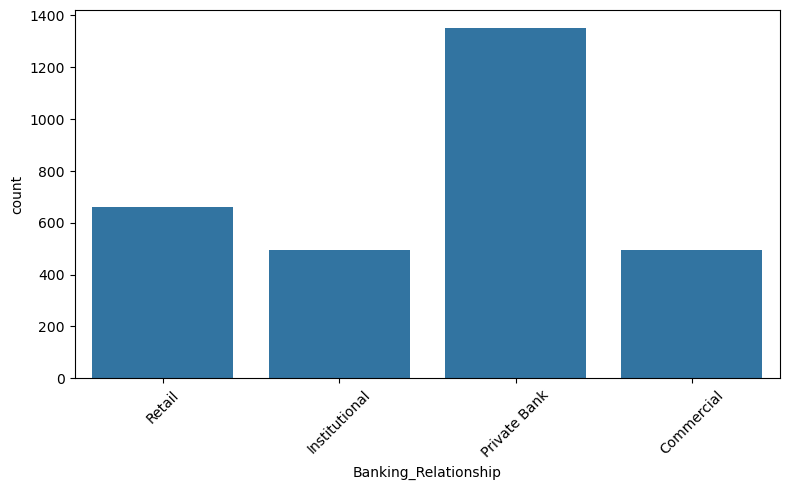

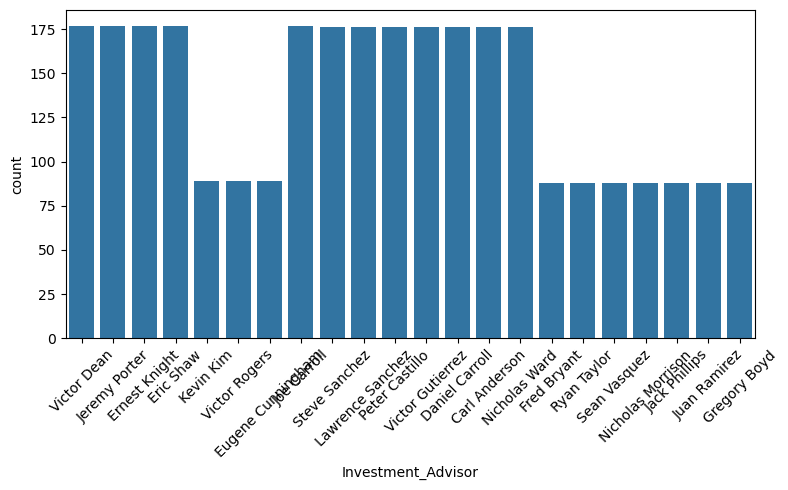

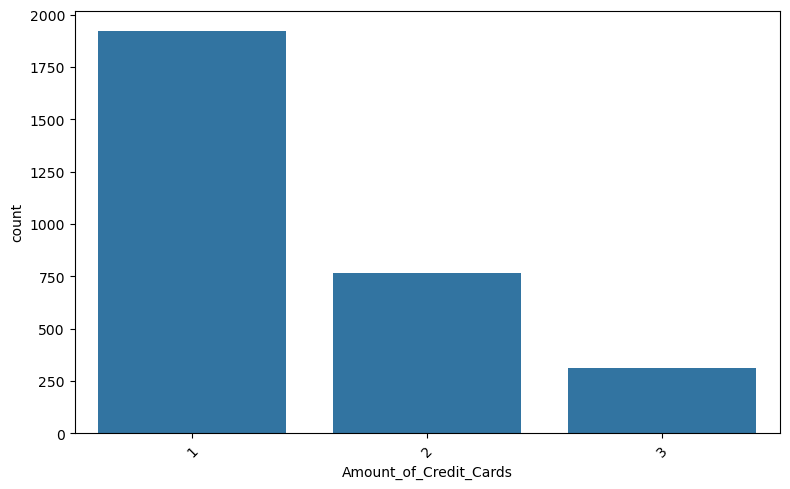

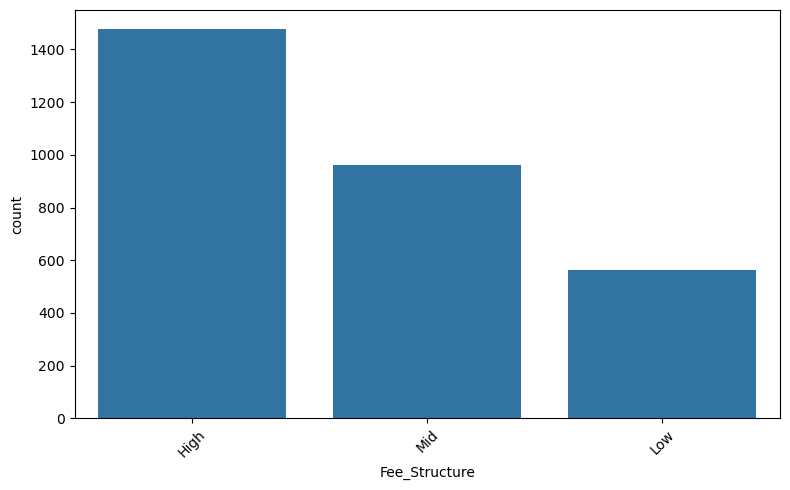

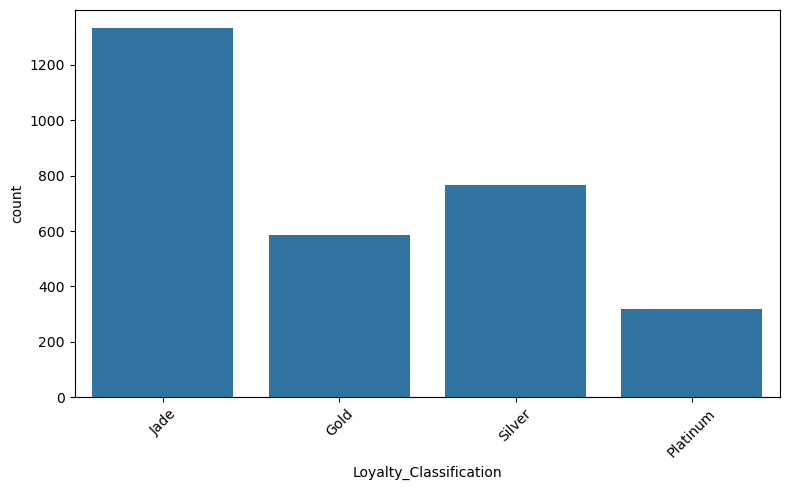

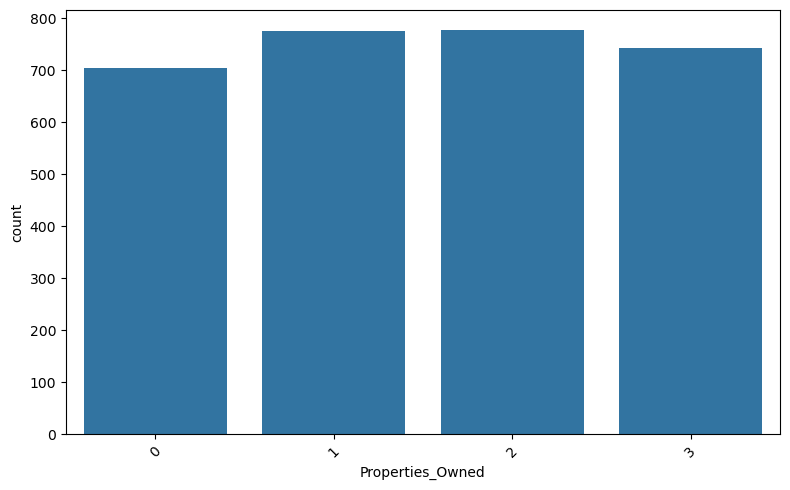

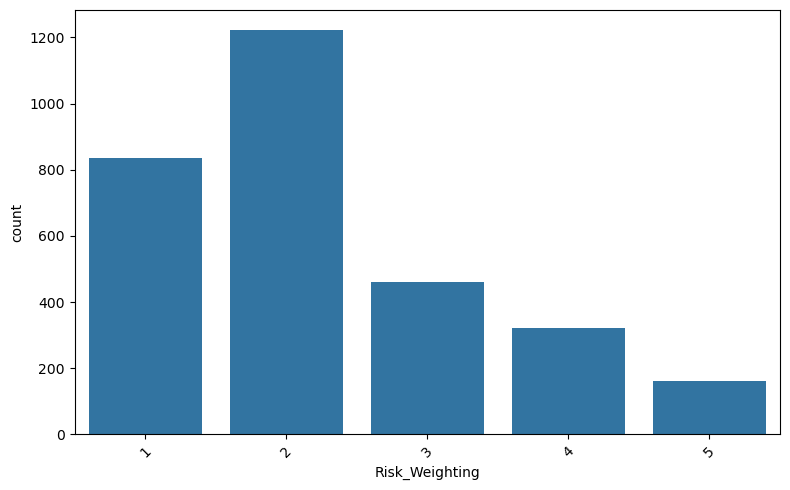

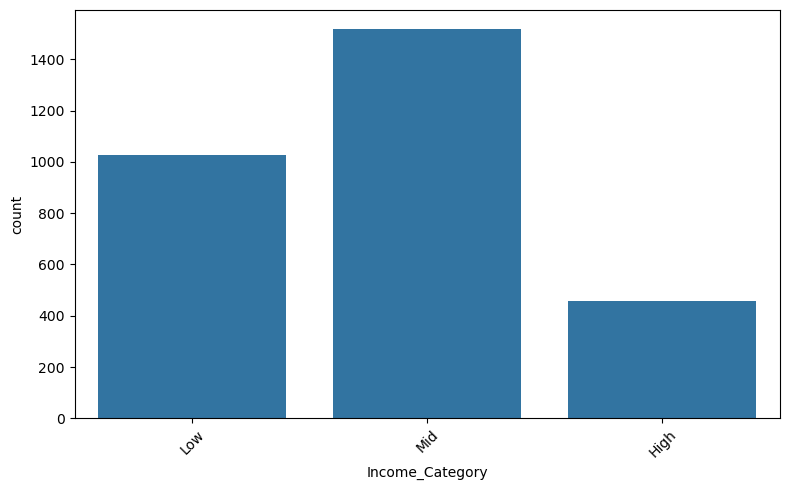

In [16]:
categorical_cols = [
    "Banking_Relationship",
    "Investment_Advisor",
    "Amount_of_Credit_Cards",
    "Fee_Structure",
    "Loyalty_Classification",
    "Properties_Owned",
    "Risk_Weighting",
    "Income_Category"
]

for predictor in categorical_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.countplot(
        data=df,
        x=predictor
    )
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

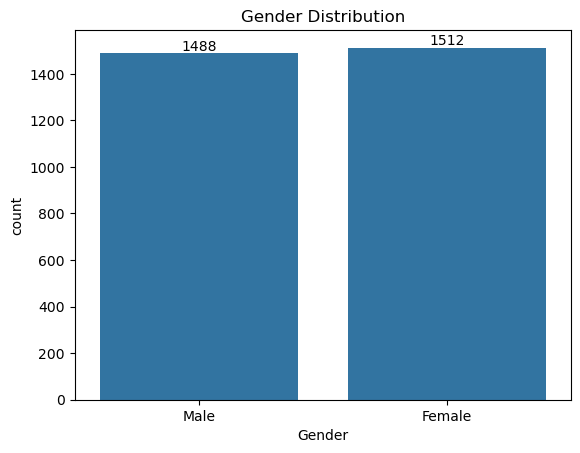

In [17]:
#Gender Distribution
ax = sns.countplot(data=df, x='Gender')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Gender Distribution')
plt.show()

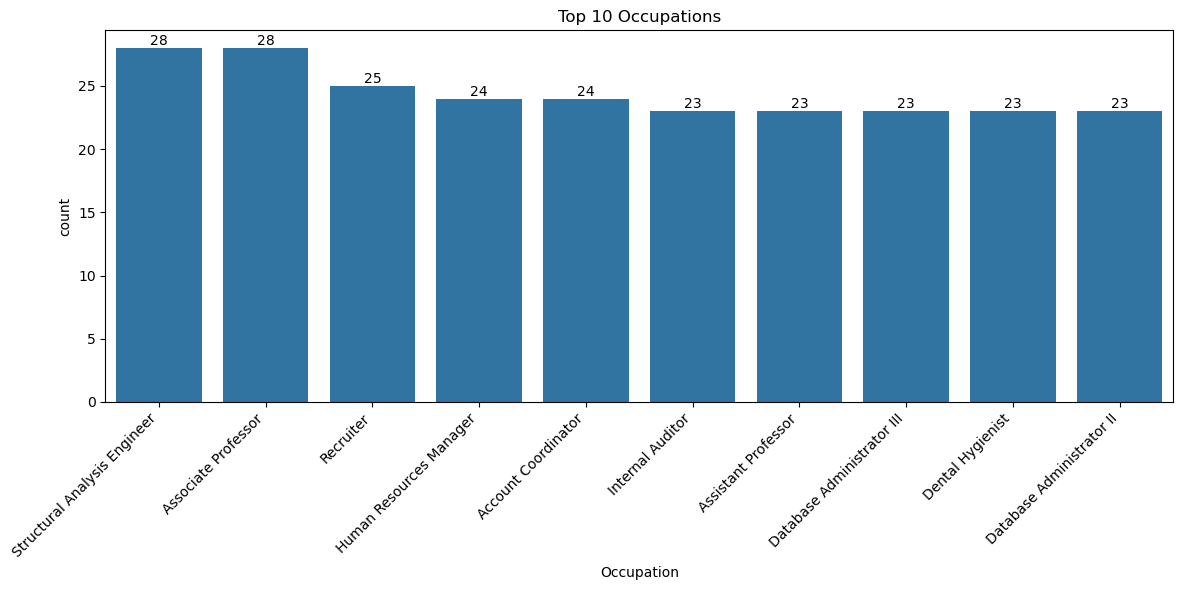

In [18]:
#top 10 occupation
top_occ = df['Occupation'].value_counts().head(10).index

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df[df['Occupation'].isin(top_occ)],
    x='Occupation',
    order=top_occ
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Occupations")
plt.tight_layout()

plt.show()

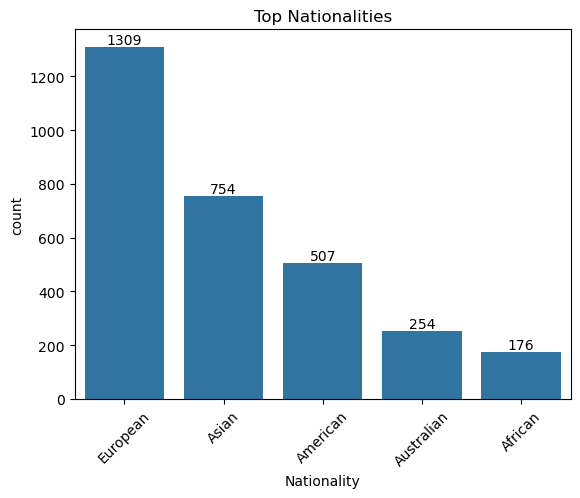

In [19]:
#Nationality analysis
top_nat = df['Nationality'].value_counts().head(10).index

ax = sns.countplot(
    data=df[df['Nationality'].isin(top_nat)],
    x='Nationality',
    order=top_nat
)

for container in ax.containers:
    ax.bar_label(container)
    
plt.xticks(rotation=45)
plt.title("Top Nationalities")
plt.show()

### Bivariate Analysis

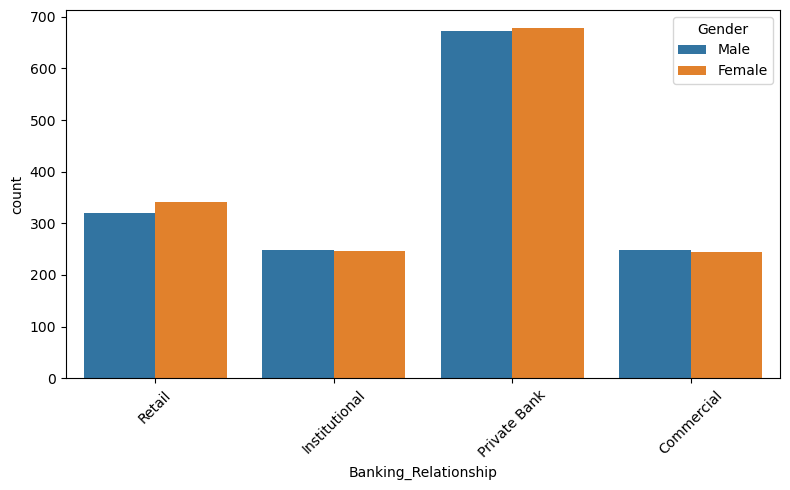

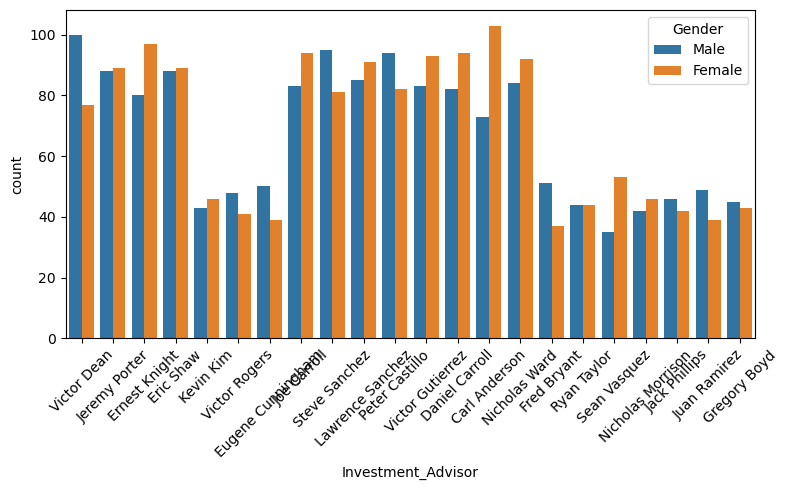

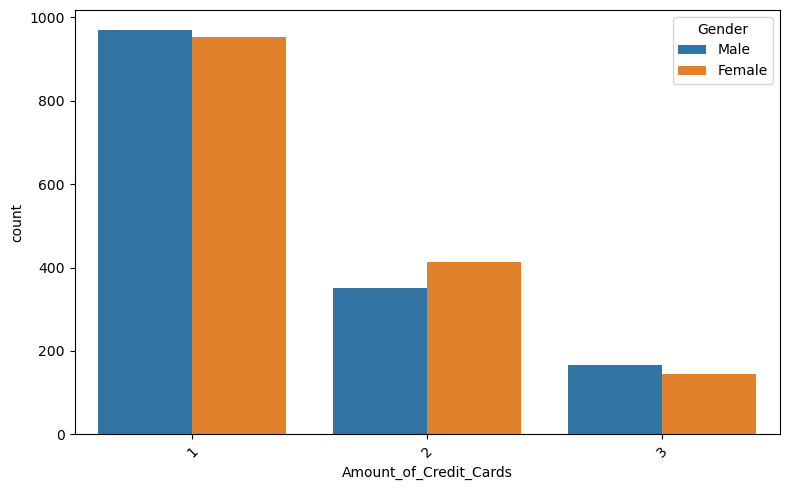

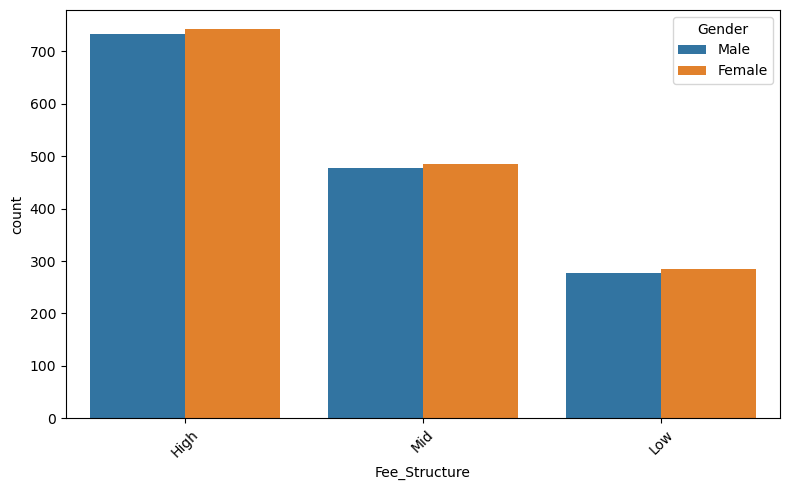

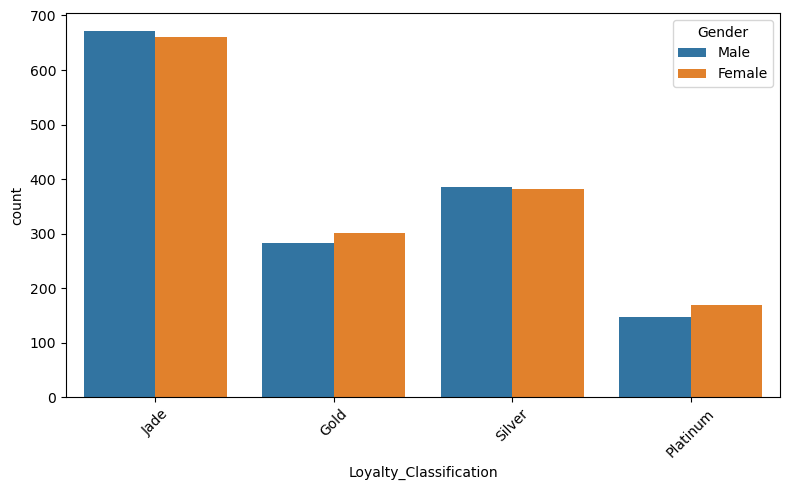

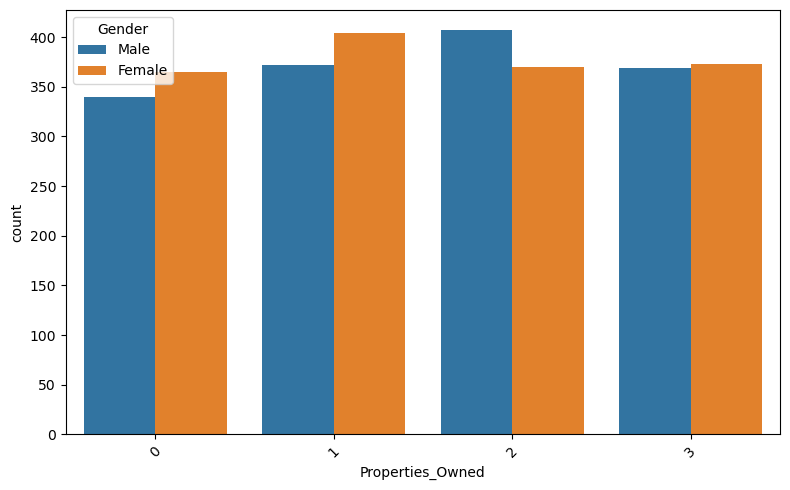

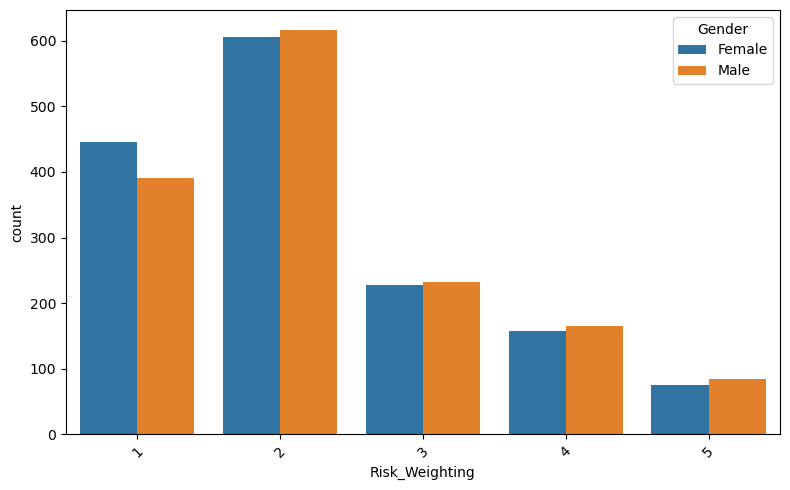

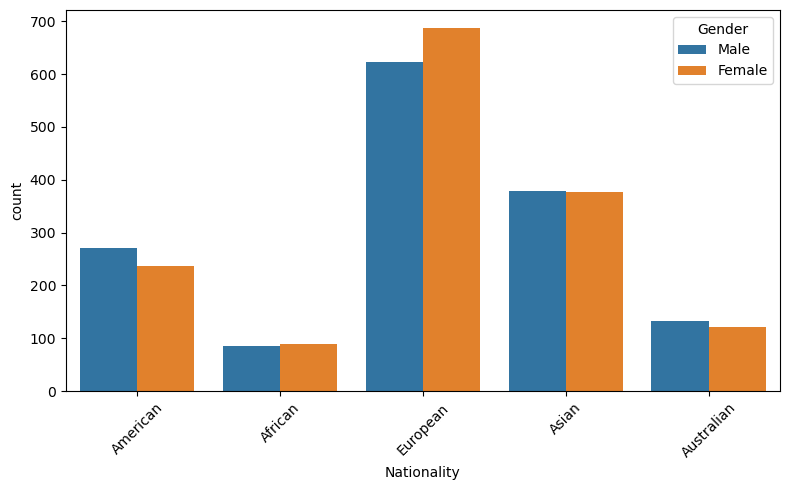

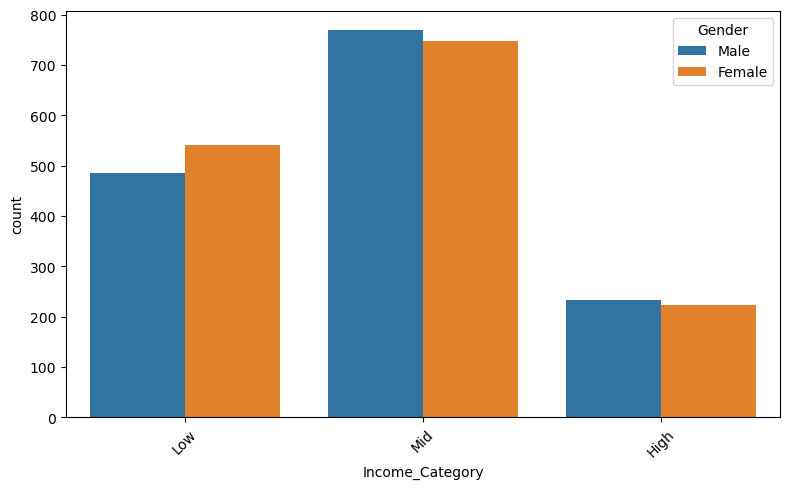

In [20]:

categorical_cols = [
    "Banking_Relationship",
    "Investment_Advisor",
    "Amount_of_Credit_Cards",
    "Fee_Structure",
    "Loyalty_Classification",
    "Properties_Owned",
    "Risk_Weighting",
    "Nationality",
    "Income_Category"
]

for predictor in categorical_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.countplot(
        data=df,
        x=predictor,
        hue='Gender'
    )
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

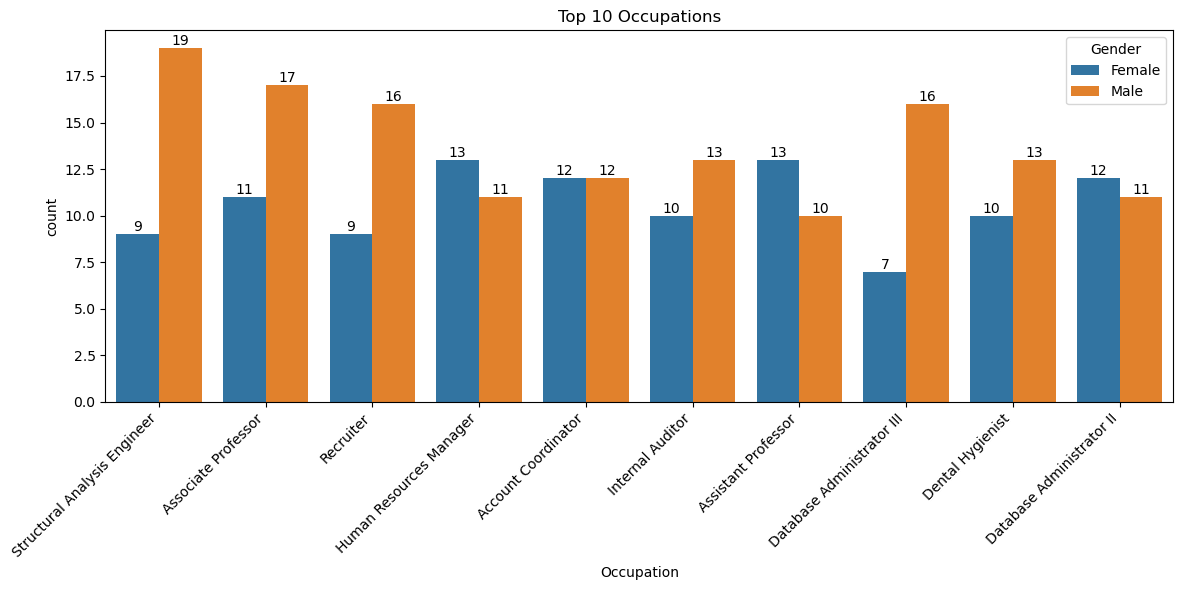

In [21]:
#Top 10 occupation

#top 10 occupation by Gender
top_occ = df['Occupation'].value_counts().head(10).index

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df[df['Occupation'].isin(top_occ)],
    x='Occupation',
    order=top_occ,
    hue='Gender'
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Occupations")
plt.tight_layout()

plt.show()

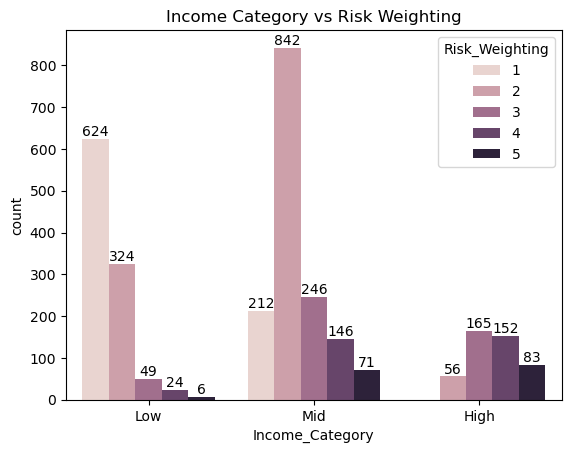

In [22]:
#Income Category vs Risk Weighting
ax = sns.countplot(
    data=df,
    x='Income_Category',
    hue='Risk_Weighting'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Income Category vs Risk Weighting")
plt.show()

### Insights from the above chart 
- Which income groups are high risk
- Whether low-income customers dominate risky segments

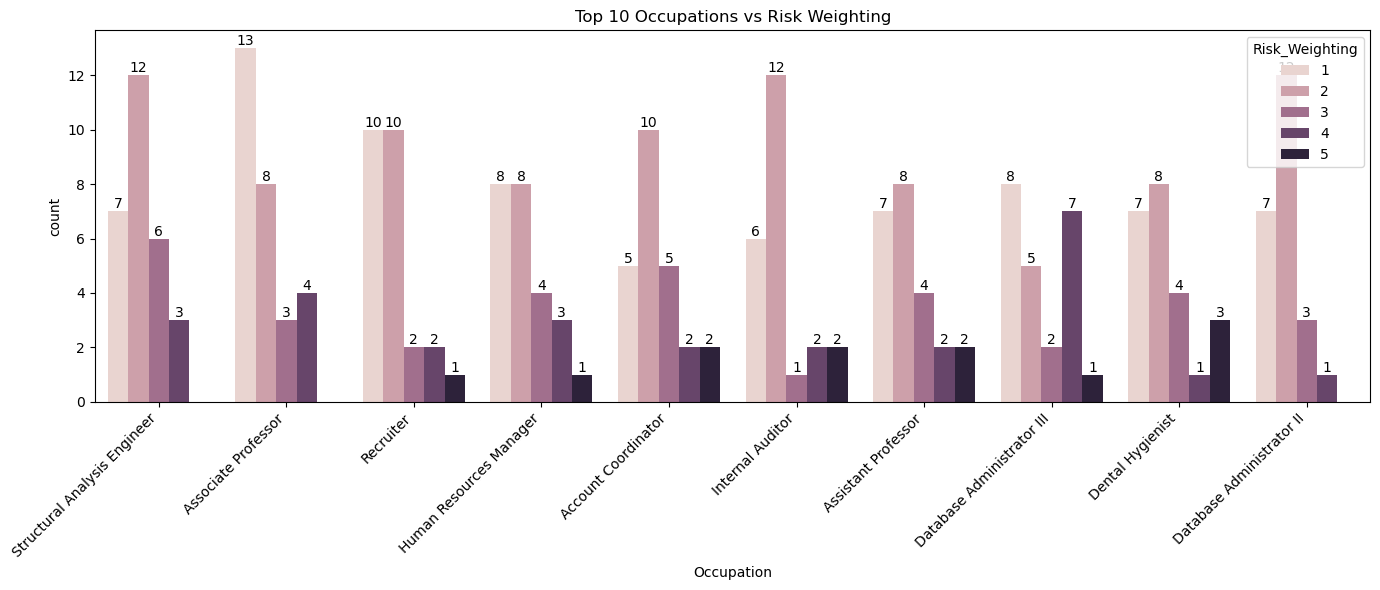

In [23]:
#Occupation vs Risk Weighting
top_occ = df['Occupation'].value_counts().head(10).index

plt.figure(figsize=(14,6))

ax = sns.countplot(
    data=df[df['Occupation'].isin(top_occ)],
    x='Occupation',
    hue='Risk_Weighting',
    order=top_occ
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45, ha='right')

plt.title("Top 10 Occupations vs Risk Weighting")

plt.tight_layout()
plt.show()

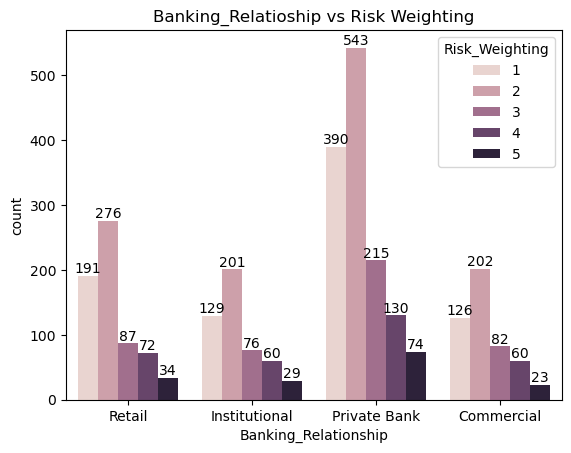

In [24]:
#Banking Relationship vs Risk Weighting
ax = sns.countplot(
    data=df,
    x='Banking_Relationship',
    hue='Risk_Weighting'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Banking_Relatioship vs Risk Weighting")
plt.show()

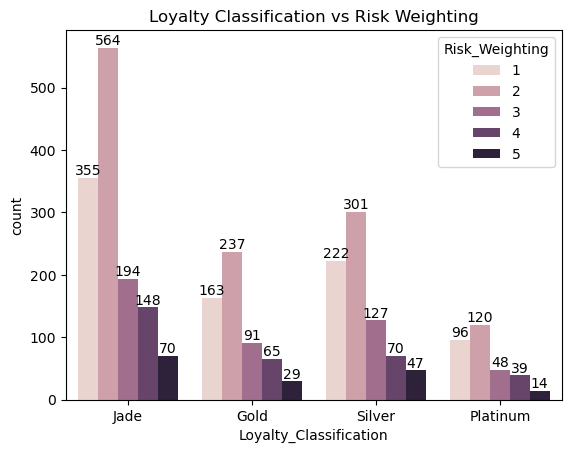

In [25]:
#Loyalty Classification vs Risk Weighting

ax = sns.countplot(
    data = df,
    x = 'Loyalty_Classification',
    hue = 'Risk_Weighting'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Loyalty Classification vs Risk Weighting")
plt.show()
    

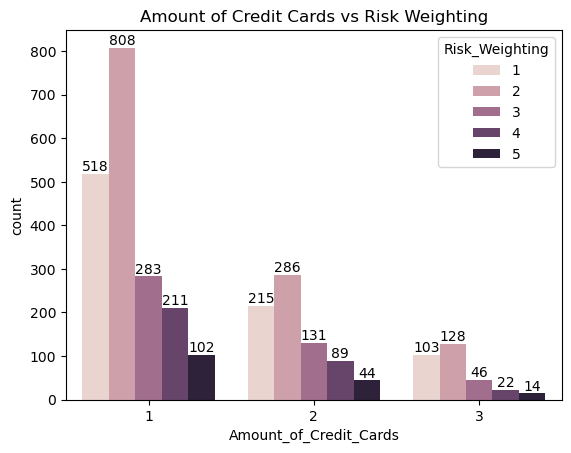

In [26]:
#Credit Card vs Risk Weighting

ax = sns.countplot(
    data = df,
    x = 'Amount_of_Credit_Cards',
    hue = 'Risk_Weighting'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Amount of Credit Cards vs Risk Weighting")
plt.show()

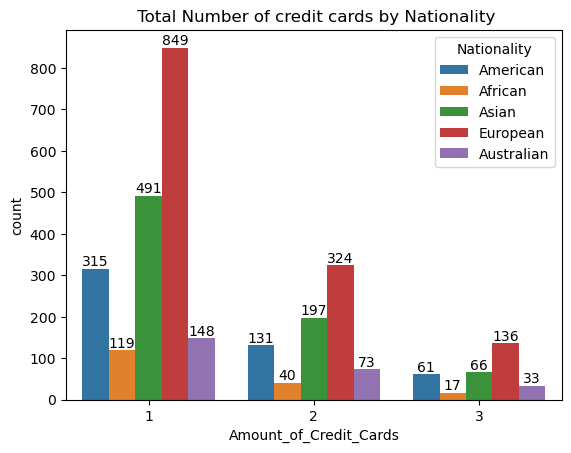

In [27]:
#Number of credit cards by nationality

ax = sns.countplot(
    data = df,
    x = 'Amount_of_Credit_Cards',
    hue = 'Nationality'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(" Total Number of credit cards by Nationality")
plt.show()

### Numerical Analysis

In [28]:
numerical_cols = ['Age','Estimated_Income', 'Superannuation_Savings','Amount_of_Credit_Cards','Credit_Card_Balance','Bank_Loans','Bank_Deposits','Properties_Owned']

### Univariate Analysis

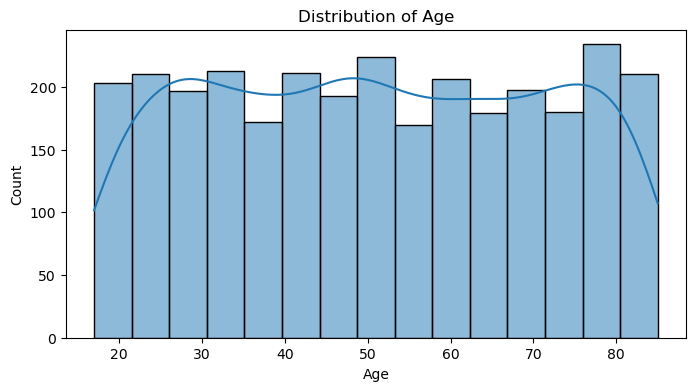

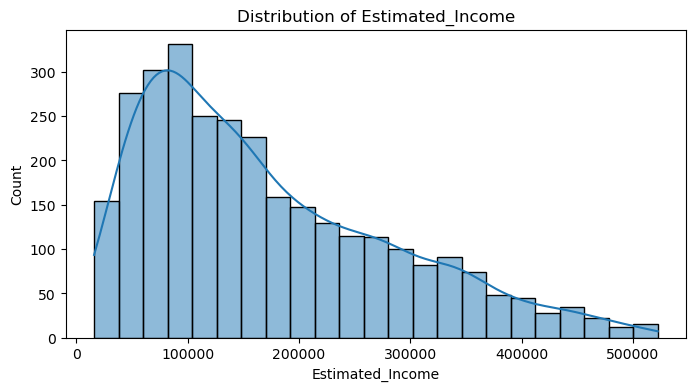

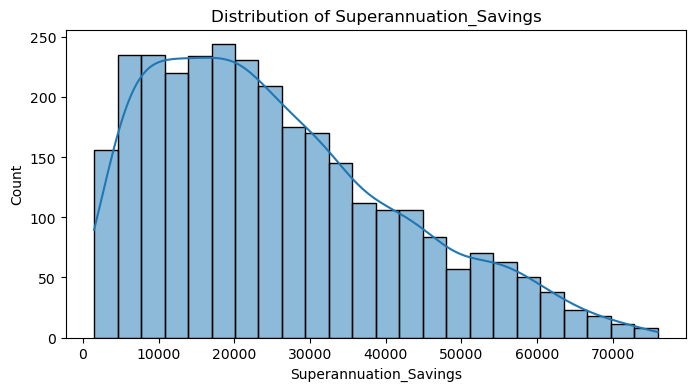

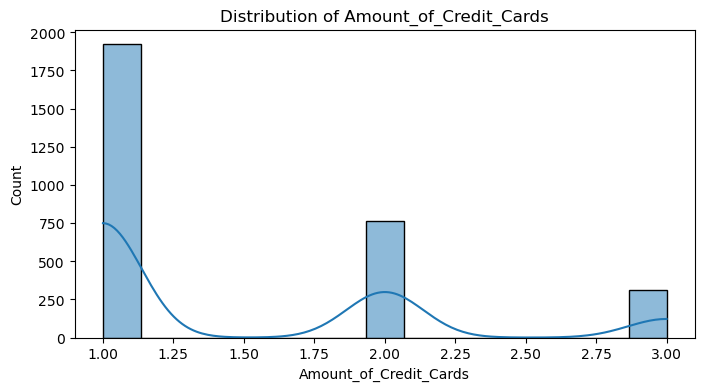

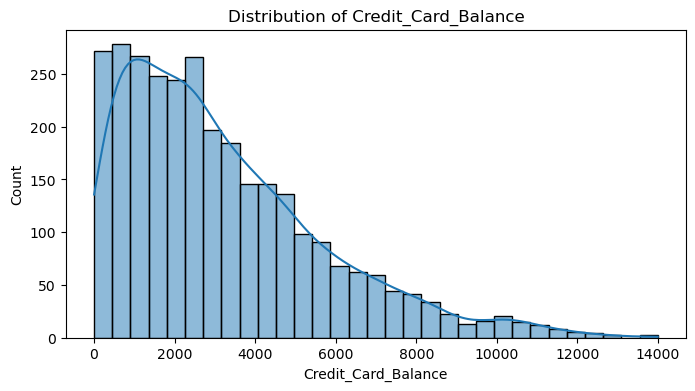

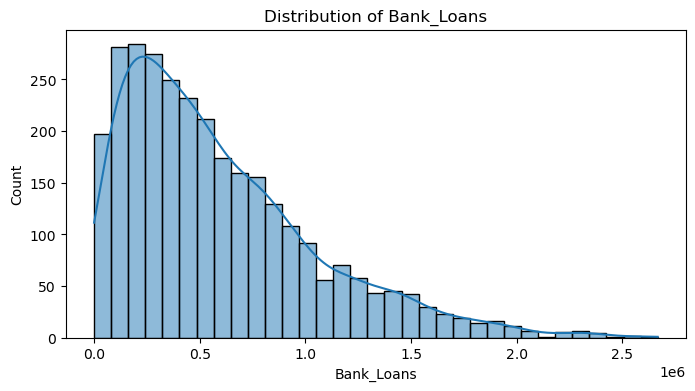

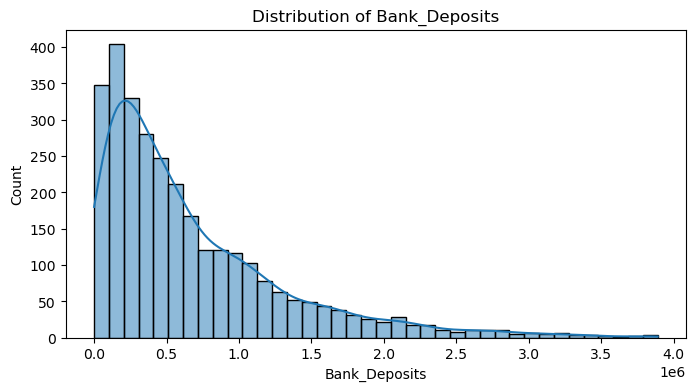

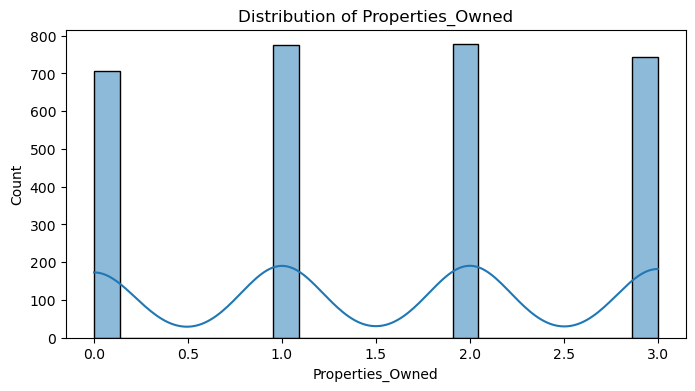

In [29]:
#Distribution
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data = df,
        x=col,
        kde=True       
    )
    plt.title(f'Distribution of {col}')
    plt.show()

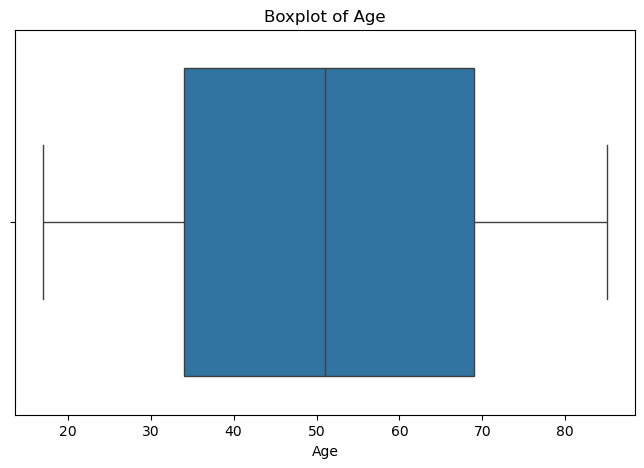

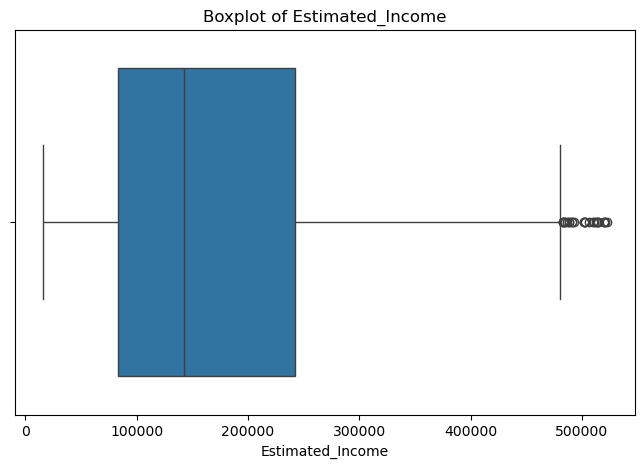

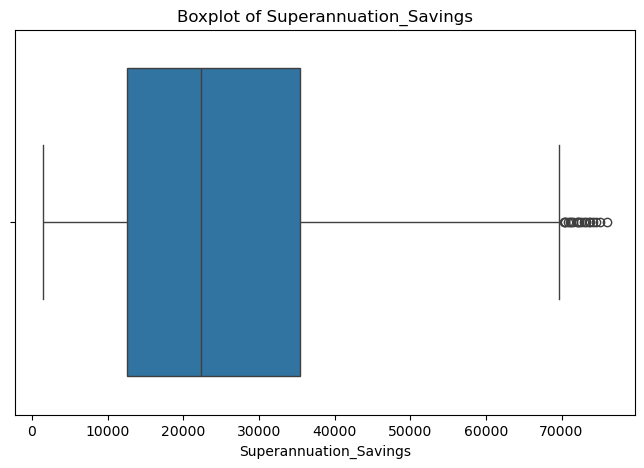

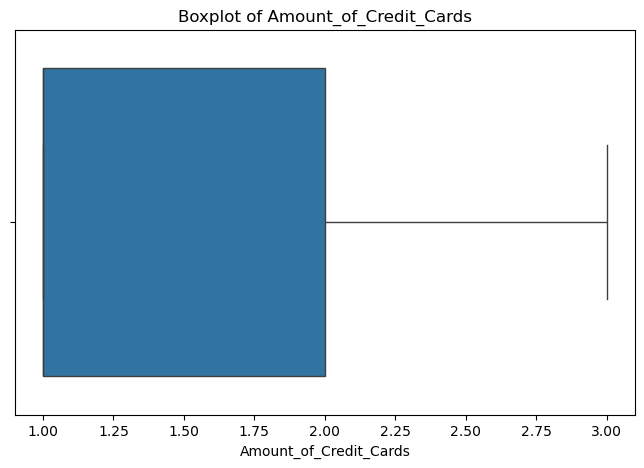

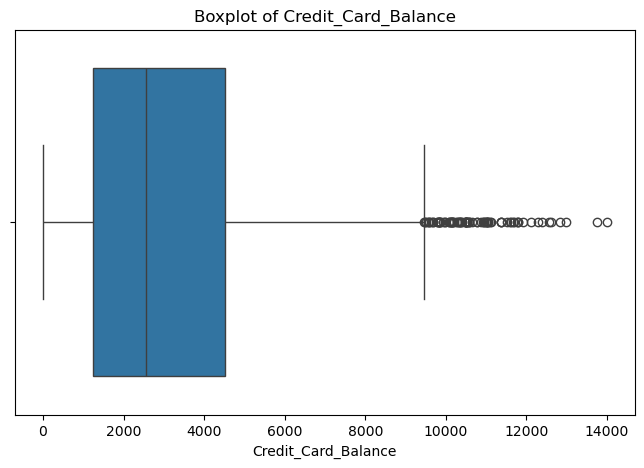

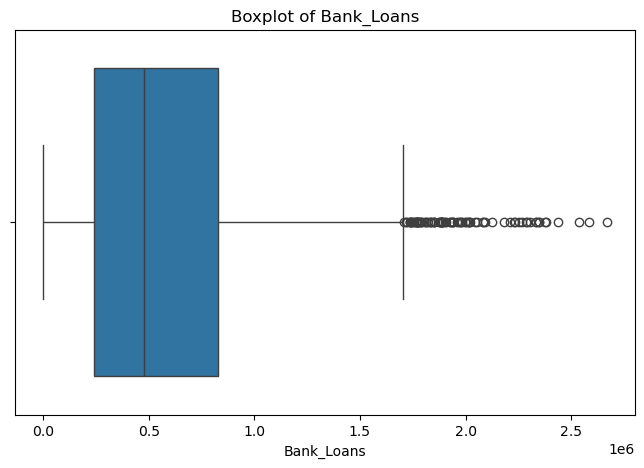

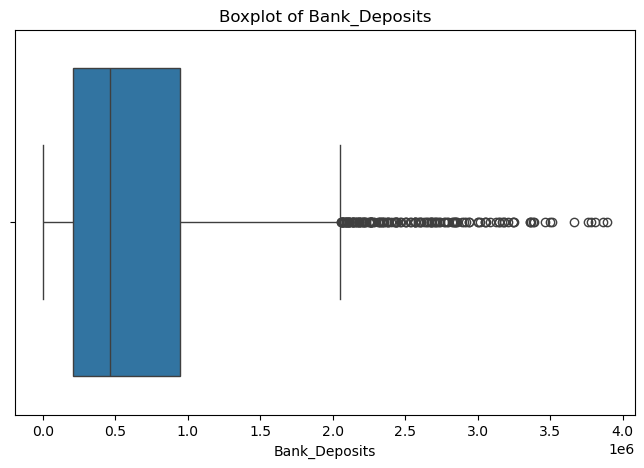

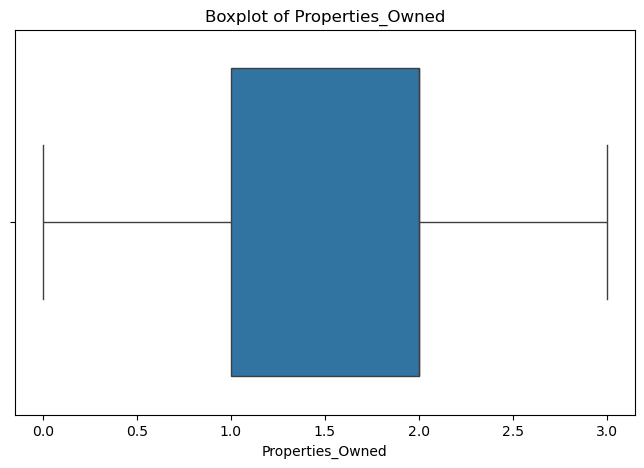

In [30]:
#For Outlier Detection

for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(f'Boxplot of {col}')

    plt.show()

In [31]:
#statistical summary
df[numerical_cols].describe()

,Age,Estimated_Income,Superannuation_Savings,Amount_of_Credit_Cards,Credit_Card_Balance,Bank_Loans,Bank_Deposits,Properties_Owned
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3000.000000
mean,51.039667,171305.034184,25531.599685,1.463667,3176.206944,5.913862e+05,6.715602e+05,1.518667
std,19.854760,111935.808180,16259.950768,0.676387,2497.094709,4.575570e+05,6.457169e+05,1.102145
min,17.000000,15919.480469,1482.030029,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000
25%,34.000000,82906.597656,12513.774902,1.000000,1236.630005,2.396281e+05,2.044004e+05,1.000000
50%,51.000000,142313.476562,22357.355469,1.000000,2560.804932,4.797934e+05,4.633165e+05,2.000000
75%,69.000000,242290.300781,35464.741211,2.000000,4522.632690,8.258130e+05,9.427546e+05,2.000000
max,85.000000,522330.250000,75963.898438,3.000000,13991.990234,2.667557e+06,3.890598e+06,3.000000


### Bivariate Analysis

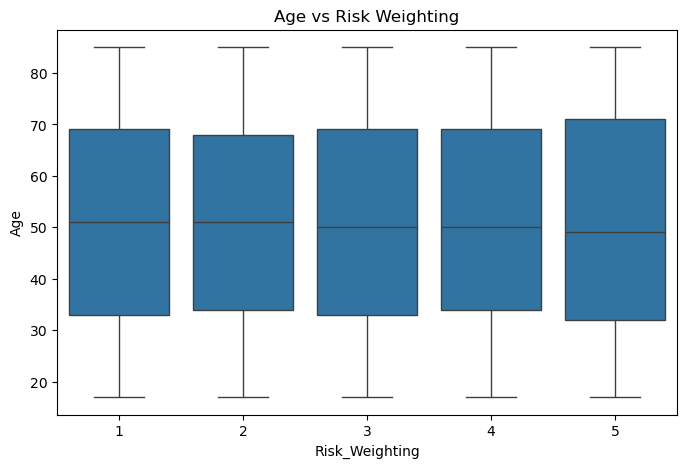

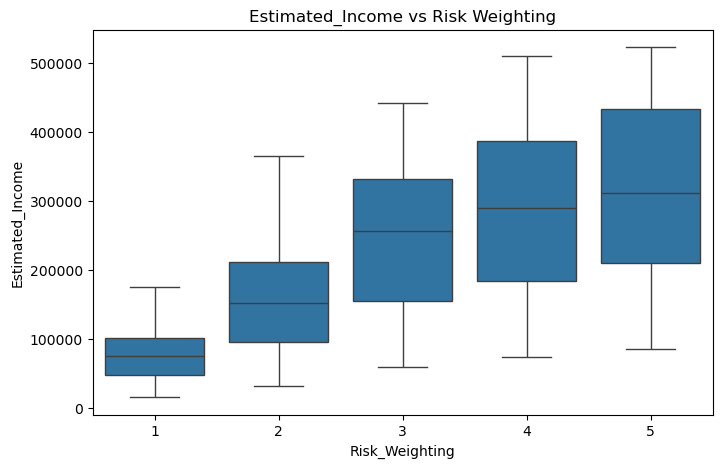

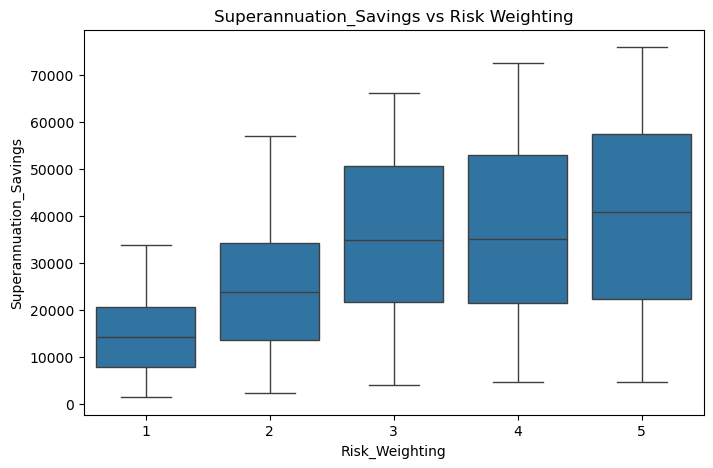

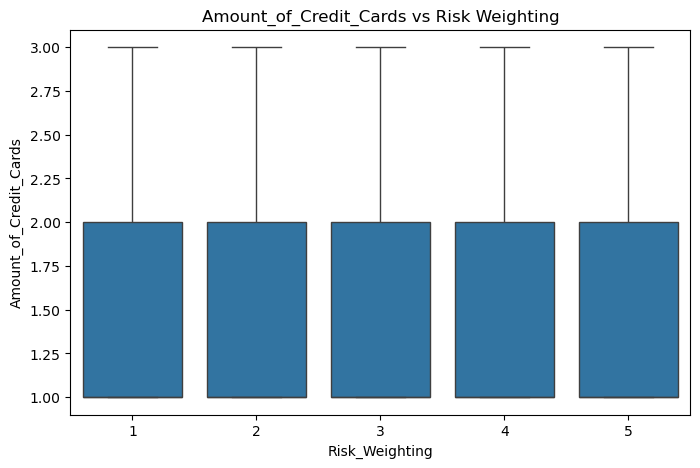

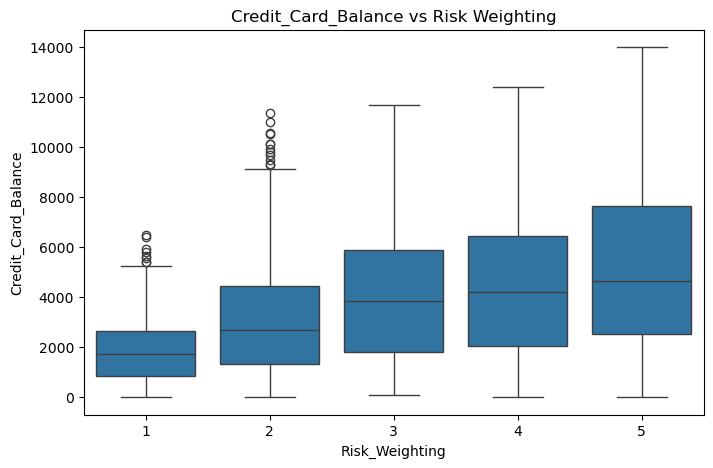

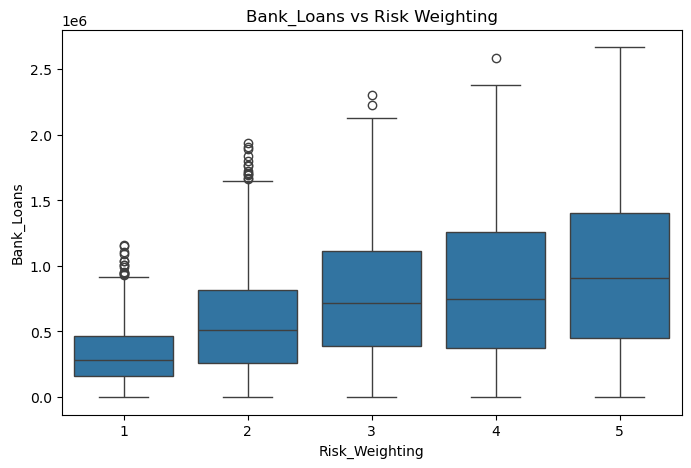

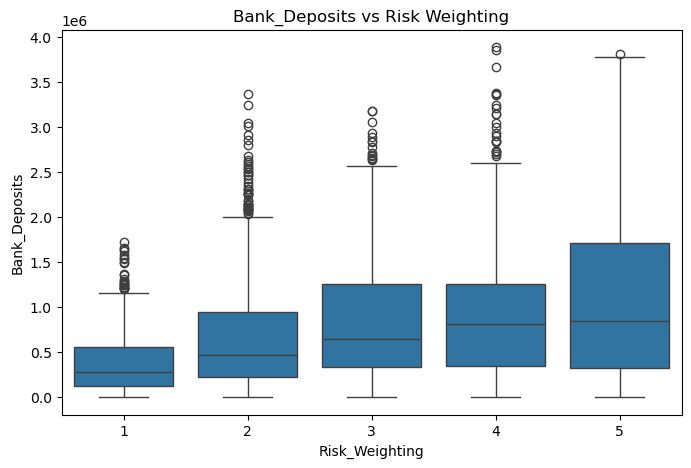

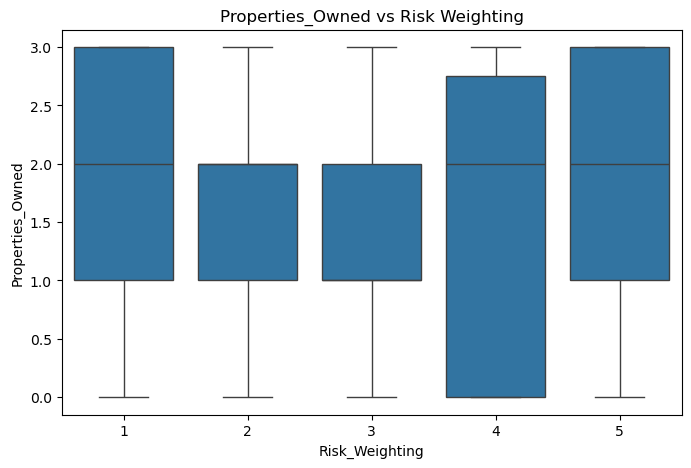

In [32]:
#Boxplot Against Risk Weighting
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x='Risk_Weighting',
        y=col
    )

    plt.title(f'{col} vs Risk Weighting')

    plt.show()

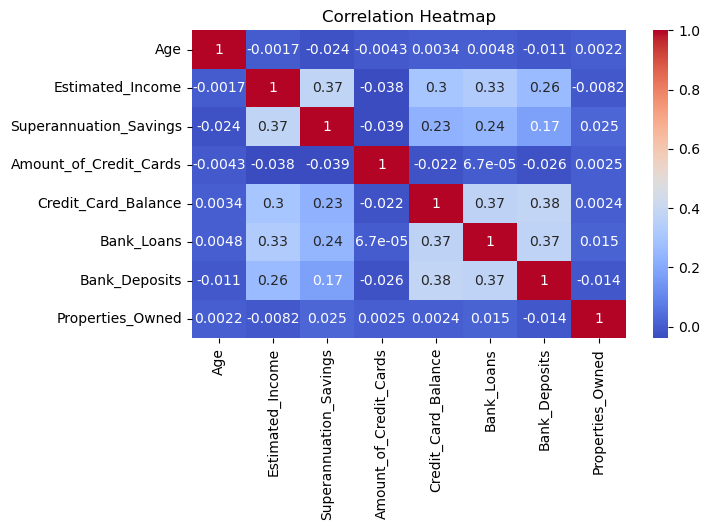

In [33]:
plt.figure(figsize=(7,4))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Insights:

* `Estimated_Income` has a moderate positive correlation with `Superannuation_Savings` (`0.37`), indicating higher-income customers tend to have higher savings.

* `Credit_Card_Balance` is positively correlated with both `Bank_Deposits` (`0.38`) and `Bank_Loans` (`0.37`), suggesting financially active customers use more credit and banking products.

* `Estimated_Income` shows positive relationships with `Bank_Loans` (`0.33`) and `Credit_Card_Balance` (`0.30`), implying higher-income customers tend to borrow and spend more.

* `Age` has very weak correlation with most financial variables, indicating limited influence on banking behavior in this dataset.

* `Properties_Owned` and `Amount_of_Credit_Cards` show minimal correlation with other numerical features.

* No strong correlations above `0.8` are present, indicating low multicollinearity among numerical variables, which is beneficial for machine learning models.


In [34]:
df

,Client_ID,Name,Age,Location_ID,Joined_Bank,Banking_Contact,Nationality,Occupation,Fee_Structure,Loyalty_Classification,...,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,Gender,Banking_Relationship,Investment_Advisor,Income_Category
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,6.036179e+05,607332.437500,12249.959961,1.134475e+06,1,2,Male,Retail,Victor Dean,Low
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,2.295214e+05,344635.156250,61162.308594,2.000526e+06,1,3,Male,Institutional,Jeremy Porter,Mid
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,6.526747e+05,203054.343750,79071.781250,5.481376e+05,1,3,Female,Private Bank,Ernest Knight,Mid
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1.048158e+06,234685.015625,57513.648438,1.148402e+06,0,4,Male,Commercial,Eric Shaw,High
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,4.466442e+05,128351.453125,30012.140625,1.674412e+06,0,3,Female,Retail,Kevin Kim,Mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,IND66827,Earl Hall,82,8760,2014-10-09,Joshua Bennett,American,Accounting Assistant III,High,Gold,...,5.328679e+05,657849.625000,12947.309570,1.238860e+06,1,3,Female,Private Bank,Eric Shaw,Mid
2996,IND40556,Billy Williamson,44,32837,2009-02-05,Dennis Ruiz,European,Paralegal,Mid,Gold,...,5.658174e+04,93195.609375,23205.689453,2.771711e+05,1,2,Female,Private Bank,Kevin Kim,Low
2997,IND72414,Victor Black,70,36088,2009-12-29,Joshua Ryan,American,Statistician IV,Low,Jade,...,1.587261e+05,35539.148438,30291.810547,5.029472e+05,2,2,Female,Private Bank,Victor Rogers,Low
2998,IND46652,Andrew Ford,56,24871,2006-02-13,Nicholas Cunningham,European,Human Resources Assistant III,Mid,Jade,...,4.046382e+05,56411.328125,6413.140137,1.538369e+06,3,1,Female,Private Bank,Eugene Cunningham,Mid


In [35]:
#update data in MS-Server
df.to_sql(
    name='bank_data_cleaned',
    con=engine,
    if_exists='replace',
    index=False
)

40

In [36]:
#verify the update:
query = "SELECT TOP 5 * FROM bank_data_cleaned"

pd.read_sql(query, engine)

,Client_ID,Name,Age,Location_ID,Joined_Bank,Banking_Contact,Nationality,Occupation,Fee_Structure,Loyalty_Classification,...,Checking_Accounts,Saving_Accounts,Foreign_Currency_Account,Business_Lending,Properties_Owned,Risk_Weighting,Gender,Banking_Relationship,Investment_Advisor,Income_Category
0,IND81288,Raymond Mills,24,34324,2019-05-06,Anthony Torres,American,Safety Technician IV,High,Jade,...,6.036179e+05,607332.437500,12249.959961,1.134475e+06,1,2,Male,Retail,Victor Dean,Low
1,IND65833,Julia Spencer,23,42205,2001-12-10,Jonathan Hawkins,African,Software Consultant,High,Jade,...,2.295214e+05,344635.156250,61162.308594,2.000526e+06,1,3,Male,Institutional,Jeremy Porter,Mid
2,IND47499,Stephen Murray,27,7314,2010-01-25,Anthony Berry,European,Help Desk Operator,High,Gold,...,6.526747e+05,203054.343750,79071.781250,5.481376e+05,1,3,Female,Private Bank,Ernest Knight,Mid
3,IND72498,Virginia Garza,40,34594,2019-03-28,Steve Diaz,American,Geologist II,Mid,Silver,...,1.048158e+06,234685.015625,57513.648438,1.148402e+06,0,4,Male,Commercial,Eric Shaw,High
4,IND60181,Melissa Sanders,46,41269,2012-07-20,Shawn Long,American,Assistant Professor,Mid,Platinum,...,4.466442e+05,128351.453125,30012.140625,1.674412e+06,0,3,Female,Retail,Kevin Kim,Mid
